In [16]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

project_path = Path("/Users/irinafendley/Projects/Loan_Default")

data_path = project_path / "data/processed/loan_clean.csv"

df = pd.read_csv(data_path)



In [17]:
target_dist = (
    df["Default"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
      .rename(index={False: "Repaid", True: "Defaulted"})
      .to_frame("Share of Borrowers (%)")
)

target_dist


,Share of Borrowers (%)
Default,
Repaid,88.39
Defaulted,11.61


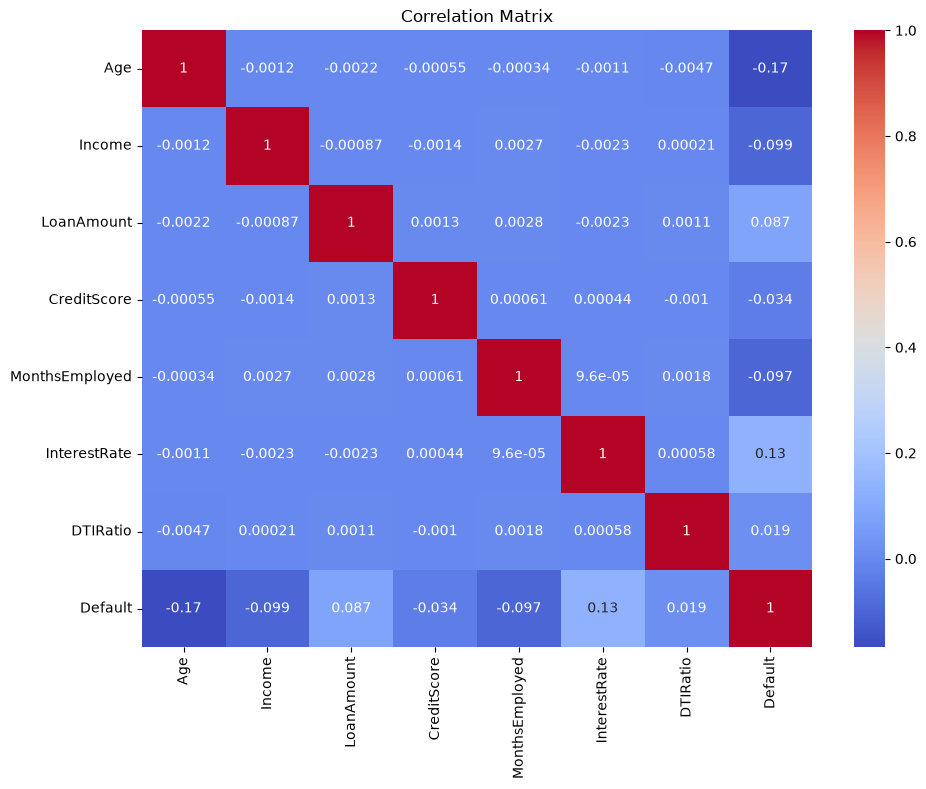

In [24]:

numeric_cols = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "InterestRate",
    "DTIRatio",
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols + ["Default"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(project_path / "visuals/correlation_heatmap.png")

plt.show()


In [31]:
corr_default = (
    df.corr(numeric_only=True)["Default"]
      .sort_values()
      .to_frame("Correlation with Default")
)

corr_default

,Correlation with Default
Age,-0.167783
Income,-0.099119
MonthsEmployed,-0.097374
HasCoSigner,-0.039109
HasDependents,-0.034678
CreditScore,-0.034166
HasMortgage,-0.022856
LoanTerm,0.000545
DTIRatio,0.019236
NumCreditLines,0.028330


In [27]:
corr_default_abs = (
    df.corr(numeric_only=True)["Default"]
      .abs()
      .sort_values(ascending=False)
)

print("Absolute Correlation with Default")
print(corr_default_abs)

Absolute Correlation with Default
Default           1.000000
Age               0.167783
InterestRate      0.131273
Income            0.099119
MonthsEmployed    0.097374
LoanAmount        0.086659
HasCoSigner       0.039109
HasDependents     0.034678
CreditScore       0.034166
NumCreditLines    0.028330
HasMortgage       0.022856
DTIRatio          0.019236
LoanTerm          0.000545
Name: Default, dtype: float64


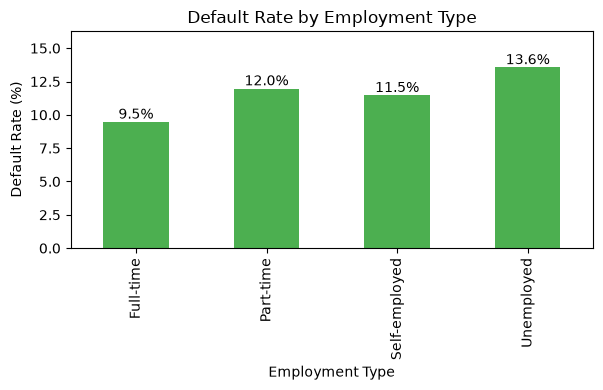

In [19]:
cat_risk = (
    df.groupby("EmploymentType")["Default"]
      .mean() * 100
)
plt.figure(figsize=(6, 4))

ax = cat_risk.plot(
    kind="bar",
    color="#4CAF50" 
)

plt.title("Default Rate by Employment Type")
plt.ylabel("Default Rate (%)")
plt.xlabel("Employment Type")

plt.ylim(0, cat_risk.max() * 1.2)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig(project_path / "visuals/employment_risk.png", dpi=300)
plt.show()

In [20]:
print(df.groupby('EmploymentType')['Default'].mean().sort_values(ascending=False))


EmploymentType
Unemployed       0.135529
Part-time        0.119652
Self-employed    0.114620
Full-time        0.094634
Name: Default, dtype: float64


<Figure size 600x500 with 0 Axes>

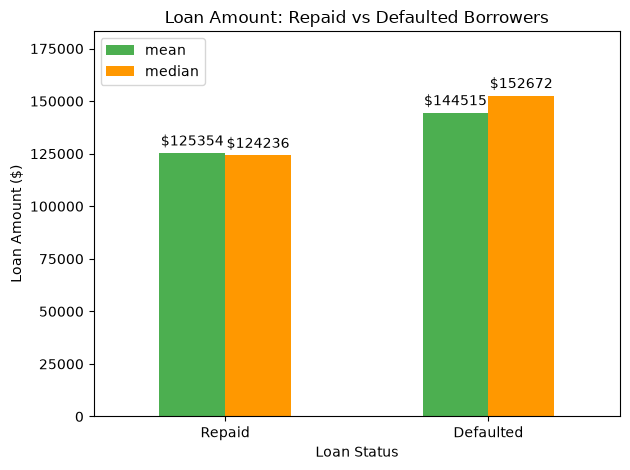

In [39]:
loan_summary = df.groupby("Default")["LoanAmount"].agg(
    ["mean", "median"]
)

loan_summary.index = ["Repaid", "Defaulted"]

plt.figure(figsize=(6, 5))

ax = loan_summary.plot(kind="bar", color=["#4CAF50", "#FF9800"])

plt.title("Loan Amount: Repaid vs Defaulted Borrowers")
plt.ylabel("Loan Amount ($)")
plt.xlabel("Loan Status")

plt.xticks(rotation=0)
plt.ylim(0, loan_summary.max().max() * 1.2)

for container in ax.containers:
    ax.bar_label(container, fmt="$%.0f", padding=3)

plt.tight_layout()
plt.savefig(project_path / "visuals/loan_amount_summary.png", dpi=300)
plt.show()


In [25]:
loan_summary = df.groupby("Default")["LoanAmount"].agg(
    ["count", "mean", "median", "min", "max"]
)

loan_summary.index = ["Repaid", "Defaulted"]

print("Loan Amount Summary by Default Status")
print("-------------------------------------")

print(loan_summary.round(1))

Loan Amount Summary by Default Status
-------------------------------------
            count      mean    median   min     max
Repaid     225694  125353.7  124236.0  5001  249999
Defaulted   29653  144515.3  152672.0  5000  249993


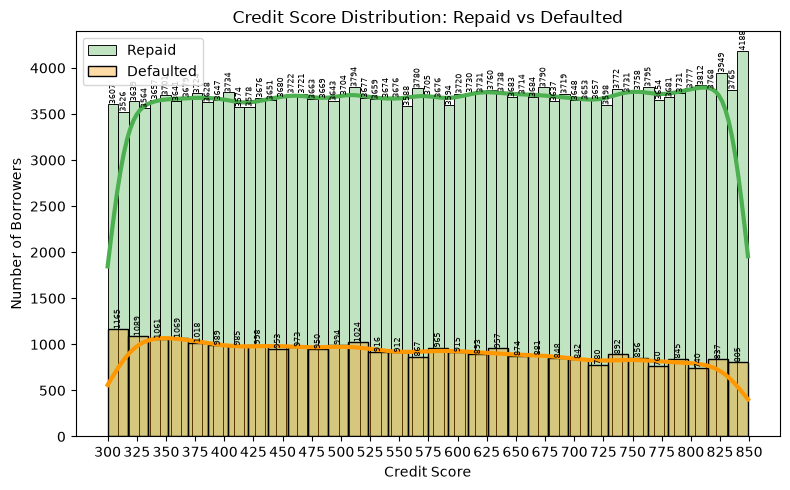

In [38]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    data=df[df["Default"] == 0],
    x="CreditScore",
    color="#4CAF50",
    label="Repaid",
    alpha=0.35,
    kde=True,
    line_kws={"linewidth": 3, "color": "#1B5E20"}
)

sns.histplot(
    data=df[df["Default"] == 1],
    x="CreditScore",
    color="#FF9800",
    label="Defaulted",
    alpha=0.35,
    kde=True,
    ax=ax,
    line_kws={"linewidth": 3, "color": "#E65100"}
)

plt.title("Credit Score Distribution: Repaid vs Defaulted")
plt.xlabel("Credit Score")
plt.ylabel("Number of Borrowers")

plt.xticks(range(300, 851, 25), rotation=0)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=6,
            rotation=90
        )

plt.legend()
plt.tight_layout()

plt.savefig(project_path / "visuals/credit_score_distribution.png", dpi=300)

plt.show()

In [40]:
print("Credit Score Summary by Default Status")
print("--------------------------------------")

credit_summary = df.groupby("Default")["CreditScore"].agg(
    ["mean", "median", "min", "max"]
)
credit_summary.index = ["Repaid", "Defaulted"]
credit_summary.round(1)

Credit Score Summary by Default Status
--------------------------------------


,mean,median,min,max
Repaid,576.2,577.0,300,849
Defaulted,559.3,553.0,300,849


<Figure size 800x500 with 0 Axes>

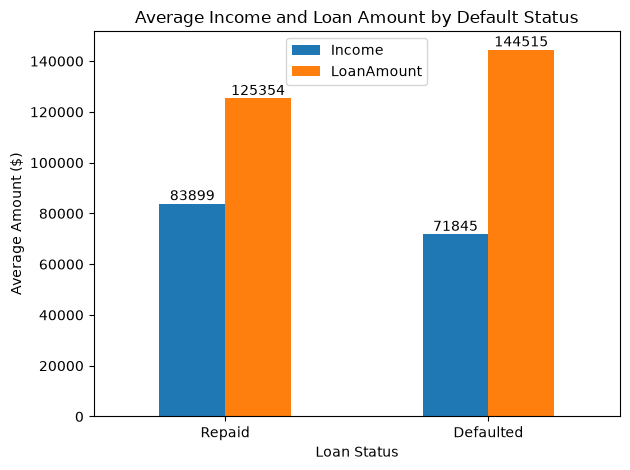

In [42]:
plt.figure(figsize=(8, 5))

ax = (
    df.groupby("Default")[["Income", "LoanAmount"]]
      .mean()
      .rename(index={False: "Repaid", True: "Defaulted"})
      .plot(kind="bar")
)

plt.title("Average Income and Loan Amount by Default Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Amount ($)")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()

plt.savefig(project_path / "visuals/income_loan_by_default.png")

plt.show()

In [41]:
print("Average Income and Loan Amount by Default Status")
print("------------------------------------------------")

income_loan_summary = df.groupby("Default")[["Income", "LoanAmount"]].mean()
income_loan_summary.index = ["Repaid", "Defaulted"]
income_loan_summary.round(1)

Average Income and Loan Amount by Default Status
------------------------------------------------


,Income,LoanAmount
Repaid,83899.2,125353.7
Defaulted,71844.7,144515.3


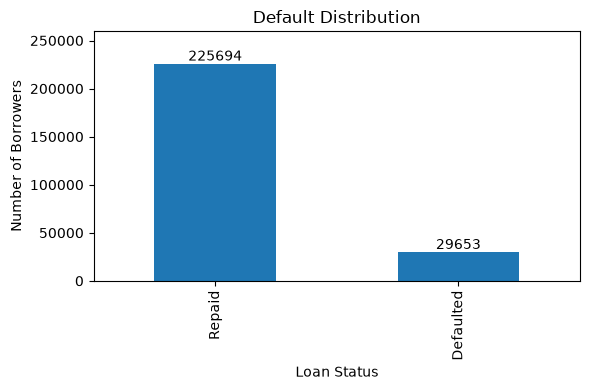

In [42]:
plt.figure(figsize=(6, 4))

ax = df["Default"].value_counts().rename({False: "Repaid", True: "Defaulted"}).plot(kind="bar")

plt.title("Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Borrowers")

for container in ax.containers:
    ax.bar_label(container)
plt.ylim(0, df["Default"].value_counts().max() * 1.15)
plt.tight_layout()
plt.savefig(project_path / "visuals/default_distribution.png")
plt.show()

In [4]:
print("Default Distribution (counts and %)")

default_dist = df["Default"].value_counts()
default_pct = df["Default"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "count": default_dist,
    "percent": default_pct.round(2)
})

summary.index = ["Repaid", "Defaulted"]
summary

Default Distribution (counts and %)


,count,percent
Repaid,225694,88.39
Defaulted,29653,11.61


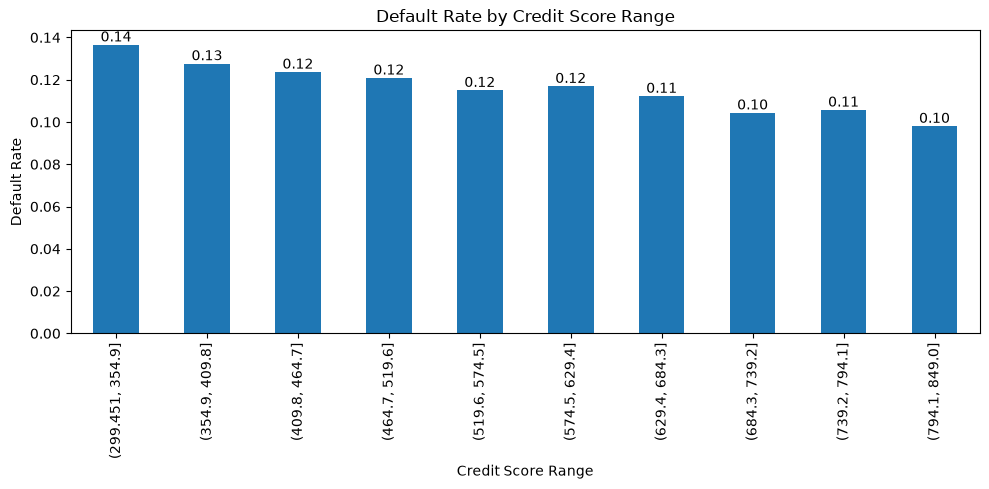

In [7]:
credit_bins = pd.cut(df["CreditScore"], bins=10)

default_rate_score = df.groupby(credit_bins)["Default"].mean()

plt.figure(figsize=(10, 5))

ax = default_rate_score.plot(kind="bar")

plt.title("Default Rate by Credit Score Range")
plt.xlabel("Credit Score Range")
plt.ylabel("Default Rate")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.savefig(project_path / "visuals/default_rate_credit_score.png")
plt.show()

In [8]:
print("Default Rate by Credit Score Range")

default_rate_score

Default Rate by Credit Score Range


CreditScore
(299.451, 354.9]    0.136527
(354.9, 409.8]      0.127636
(409.8, 464.7]      0.123685
(464.7, 519.6]      0.120882
(519.6, 574.5]      0.115022
(574.5, 629.4]      0.116924
(629.4, 684.3]      0.112256
(684.3, 739.2]      0.104364
(739.2, 794.1]      0.105717
(794.1, 849.0]      0.098034
Name: Default, dtype: float64

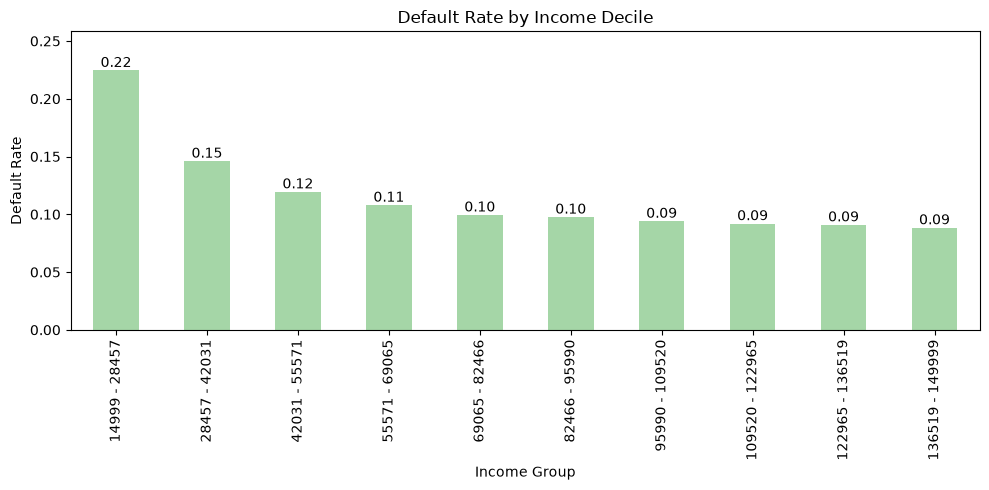

In [49]:
income_bins = pd.qcut(df["Income"], q=10)

default_rate_income = (
    df.groupby(income_bins)["Default"]
      .mean()
      .rename("Default Rate")
)

labels = [
    f"{int(interval.left)} - {int(interval.right)}"
    for interval in default_rate_income.index
]

default_rate_income.index = labels

plt.figure(figsize=(10, 5))

ax = default_rate_income.plot(
    kind="bar",
    color="#A5D6A7"
)

plt.title("Default Rate by Income Decile")
plt.xlabel("Income Group")
plt.ylabel("Default Rate")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.ylim(0, default_rate_income.max() * 1.15)

plt.tight_layout()

plt.savefig(project_path / "visuals/default_rate_income.png")

plt.show()

In [16]:
print("Default Rate by Income Deciles")

default_rate_income

Default Rate by Income Deciles


Income
(14999.999, 28457.0]    0.224654
(28457.0, 42031.0]      0.146113
(42031.0, 55571.6]      0.119575
(55571.6, 69065.0]      0.108044
(69065.0, 82466.0]      0.099554
(82466.0, 95990.2]      0.097713
(95990.2, 109520.2]     0.094106
(109520.2, 122965.0]    0.092031
(122965.0, 136519.4]    0.091016
(136519.4, 149999.0]    0.088467
Name: Default Rate, dtype: float64

In [21]:
risk_rank = (
    df.corr(numeric_only=True)["Default"]
      .abs()
      .sort_values(ascending=False)
      .drop("Default")
      .to_frame("Absolute Correlation")
)

risk_rank

,Absolute Correlation
Age,0.167783
InterestRate,0.131273
Income,0.099119
MonthsEmployed,0.097374
LoanAmount,0.086659
HasCoSigner,0.039109
HasDependents,0.034678
CreditScore,0.034166
NumCreditLines,0.028330
HasMortgage,0.022856


In [50]:
comparison = df.groupby("Default")[["Income", "LoanAmount", "CreditScore"]].mean().T

comparison.columns = ["Repaid", "Defaulted"]

comparison["Difference"] = comparison["Defaulted"] - comparison["Repaid"]

comparison.round(1)

,Repaid,Defaulted,Difference
Income,83899.2,71844.7,-12054.4
LoanAmount,125353.7,144515.3,19161.7
CreditScore,576.2,559.3,-16.9


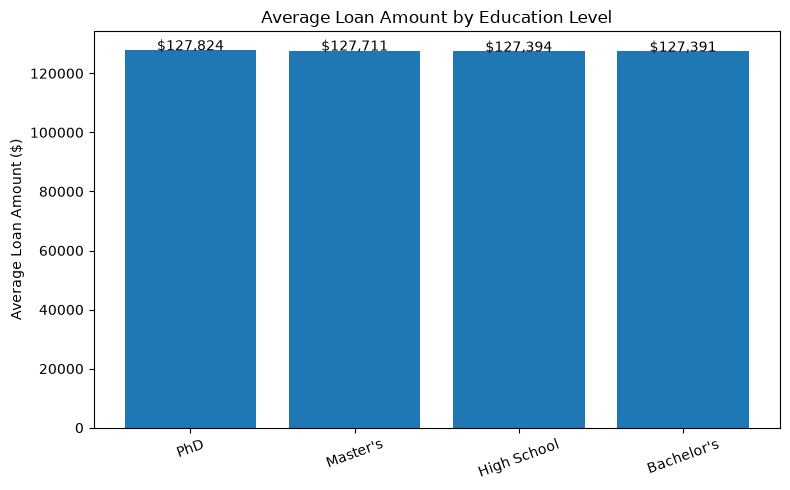


Borrowers taking the largest loans:
Education
PhD            127824.0
Master's       127711.0
High School    127394.0
Bachelor's     127391.0
Name: LoanAmount, dtype: float64


In [9]:
education_loan = (
    df.groupby("Education")["LoanAmount"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
bars = plt.bar(
    education_loan.index,
    education_loan.values
)

plt.title("Average Loan Amount by Education Level")
plt.ylabel("Average Loan Amount ($)")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center"
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("\nBorrowers taking the largest loans:")
print(education_loan.round(0))

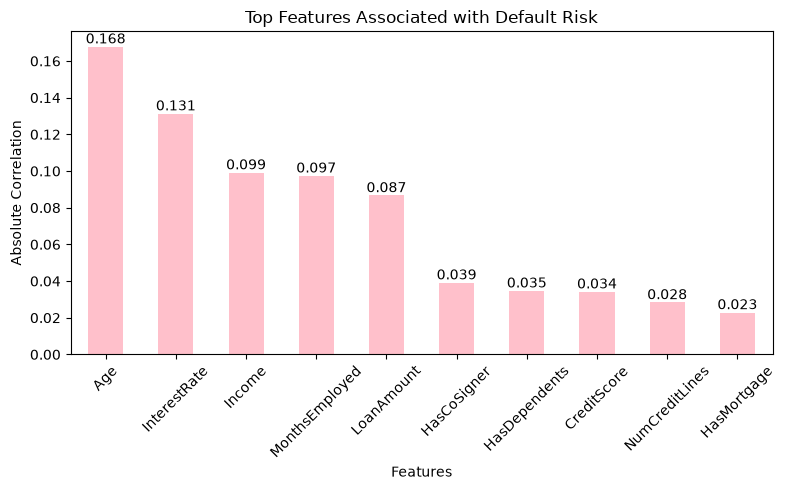

In [52]:
top_risk = (
    df.corr(numeric_only=True)["Default"]
      .abs()
      .sort_values(ascending=False)
      .drop("Default")
      .head(10)
)

plt.figure(figsize=(8, 5))

ax = top_risk.plot(kind="bar", color="pink")

plt.title("Top Features Associated with Default Risk")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(project_path / "visuals/top_risk_factors.png")
plt.show()

In [53]:
print("Top Risk Factors (Absolute Correlation with Default)")
print("---------------------------------------------------")

top_risk.round(3)

Top Risk Factors (Absolute Correlation with Default)
---------------------------------------------------


Age               0.168
InterestRate      0.131
Income            0.099
MonthsEmployed    0.097
LoanAmount        0.087
HasCoSigner       0.039
HasDependents     0.035
CreditScore       0.034
NumCreditLines    0.028
HasMortgage       0.023
Name: Default, dtype: float64

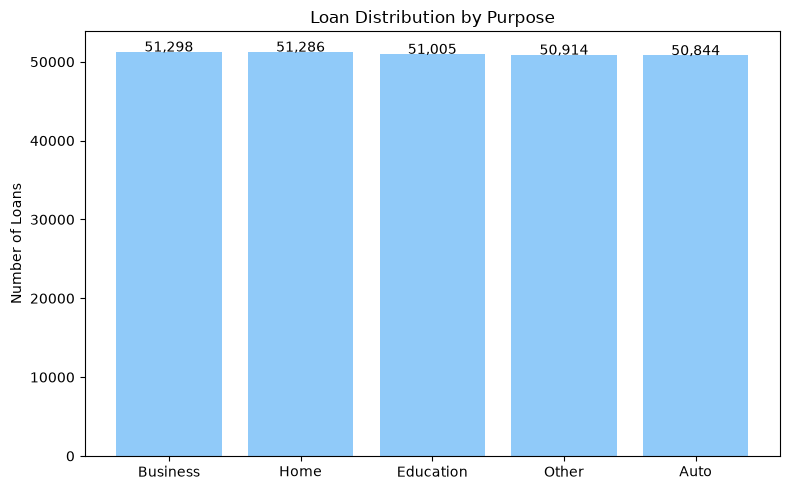


Loan Purpose Distribution:
  Loan Purpose  Number of Loans
0     Business            51298
1         Home            51286
2    Education            51005
3        Other            50914
4         Auto            50844


In [56]:
loan_purpose = df["LoanPurpose"].value_counts().reset_index()
loan_purpose.columns = ["Loan Purpose", "Number of Loans"]

plt.figure(figsize=(8,5))
bars = plt.bar(loan_purpose["Loan Purpose"],
               loan_purpose["Number of Loans"],
               color="#90CAF9")

plt.title("Loan Distribution by Purpose")
plt.ylabel("Number of Loans")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center"
    )

plt.tight_layout()
plt.savefig(project_path / "visuals/loan_purpose_distribution.png")
plt.show()

print("\nLoan Purpose Distribution:")
print(loan_purpose)

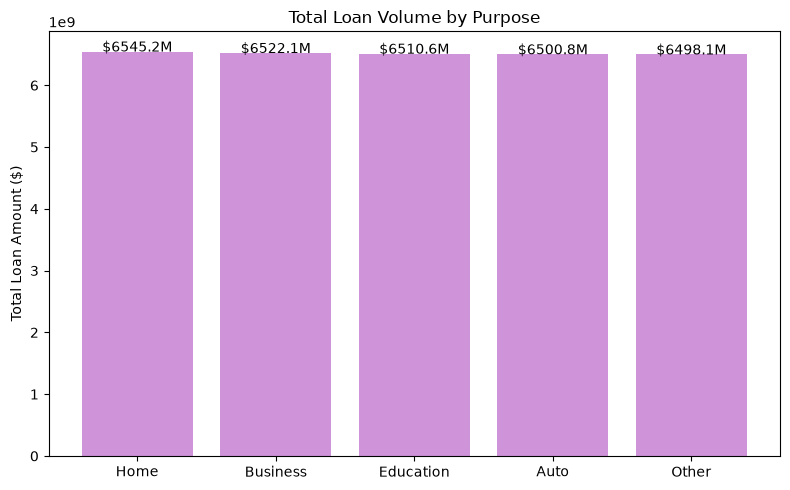


Segments generating the largest lending volume:
LoanPurpose
Home         6545241527
Business     6522120439
Education    6510575194
Auto         6500807511
Other        6498135901
Name: LoanAmount, dtype: int64


In [57]:
loan_volume = (
    df.groupby("LoanPurpose")["LoanAmount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
bars = plt.bar(loan_volume.index,
               loan_volume.values,
               color="#CE93D8")

plt.title("Total Loan Volume by Purpose")
plt.ylabel("Total Loan Amount ($)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height()/1e6:.1f}M",
        ha="center"
    )

plt.tight_layout()
plt.savefig(project_path / "visuals/loan_volume_by_purpose.png")
plt.show()

print("\nSegments generating the largest lending volume:")
print(loan_volume)

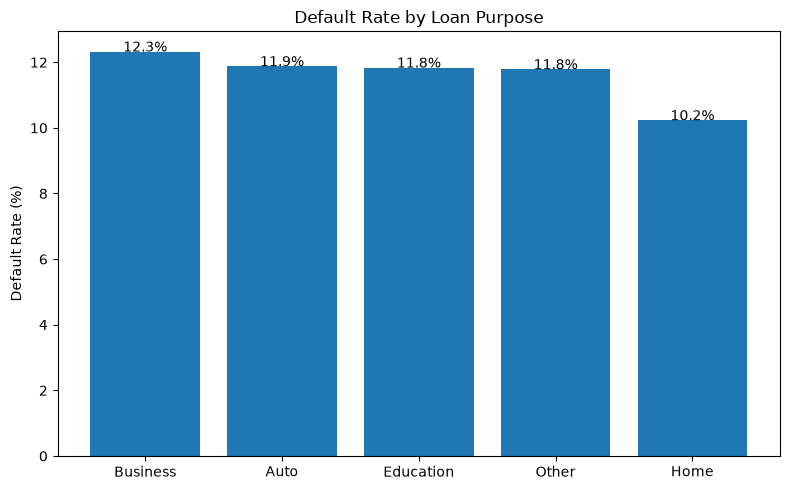


Default Rate by Loan Purpose:
LoanPurpose
Business     12.33
Auto         11.88
Education    11.84
Other        11.79
Home         10.23
Name: Default, dtype: float64


In [58]:
purpose_risk = (
    df.groupby("LoanPurpose")["Default"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

plt.figure(figsize=(8,5))
bars = plt.bar(
    purpose_risk.index,
    purpose_risk.values
)

plt.title("Default Rate by Loan Purpose")
plt.ylabel("Default Rate (%)")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig(project_path / "visuals/default_rate_by_loan_purpose.png")
plt.show()

print("\nDefault Rate by Loan Purpose:")
print(purpose_risk.round(2))

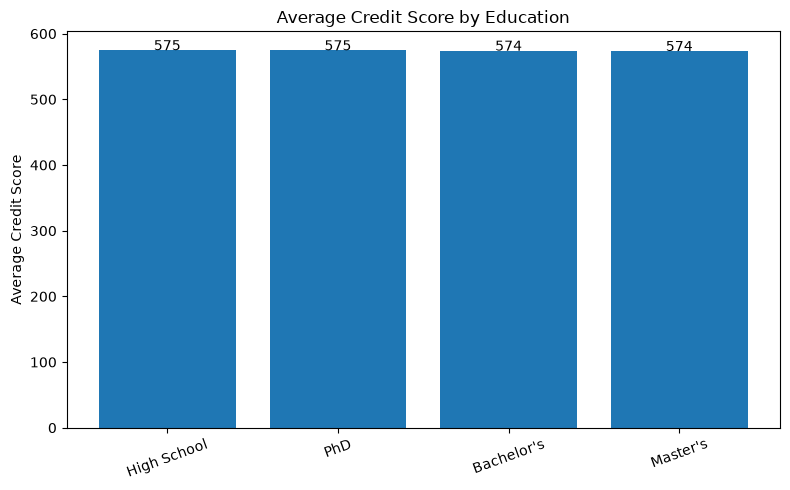


Average Credit Score by Education:
Education
High School    575.0
PhD            575.0
Bachelor's     574.0
Master's       574.0
Name: CreditScore, dtype: float64


In [59]:
education_score = (
    df.groupby("Education")["CreditScore"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
bars = plt.bar(
    education_score.index,
    education_score.values
)

plt.title("Average Credit Score by Education")
plt.ylabel("Average Credit Score")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.0f}",
        ha="center"
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(project_path / "visuals/education_credit_score.png")
plt.show()

print("\nAverage Credit Score by Education:")
print(education_score.round(0))

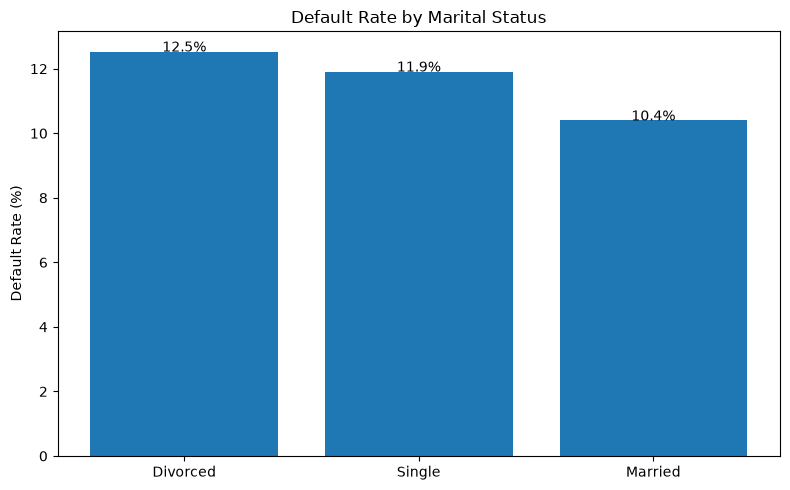


Default Rate by Marital Status:
MaritalStatus
Divorced    12.53
Single      11.91
Married     10.40
Name: Default, dtype: float64


In [60]:
marital_risk = (
    df.groupby("MaritalStatus")["Default"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

plt.figure(figsize=(8,5))
bars = plt.bar(
    marital_risk.index,
    marital_risk.values
)

plt.title("Default Rate by Marital Status")
plt.ylabel("Default Rate (%)")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig(project_path / "visuals/marital_status_default_rate.png")
plt.show()

print("\nDefault Rate by Marital Status:")
print(marital_risk.round(2))

In [12]:
df["Income Segment"] = pd.qcut(
    df["Income"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

segment_summary = (
    df.groupby("Income Segment")
      .agg(
          Borrowers=("LoanID","count"),
          AvgIncome=("Income","mean"),
          AvgLoan=("LoanAmount","mean"),
          AvgCreditScore=("CreditScore","mean"),
          DefaultRate=("Default","mean")
      )
)

segment_summary["DefaultRate"] *= 100

print(segment_summary.round(2))

                Borrowers  AvgIncome    AvgLoan  AvgCreditScore  DefaultRate
Income Segment                                                              
Low                 63837   31877.53  127624.50          574.43        17.38
Medium              63837   65653.29  127713.95          574.35        10.54
High                63839   99362.46  127344.35          574.21         9.51
Very High           63834  133105.79  127632.67          574.07         9.02


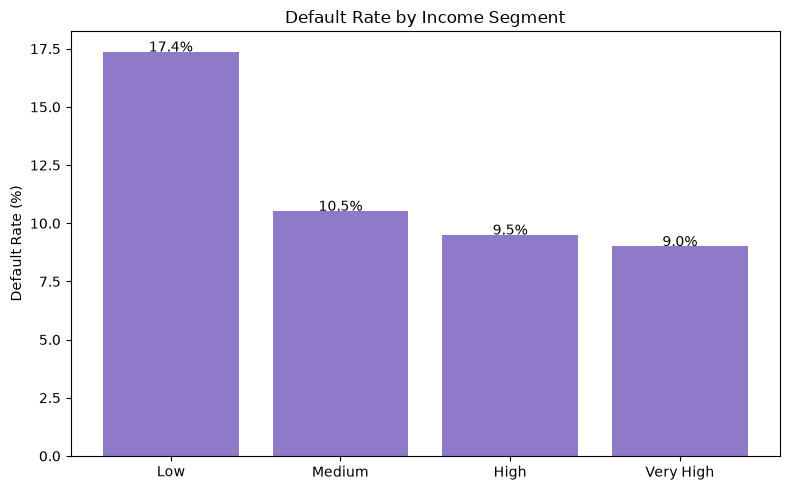

In [66]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    segment_summary.index,
    segment_summary["DefaultRate"],
    color="#8E7AC8"
)

plt.title("Default Rate by Income Segment")
plt.ylabel("Default Rate (%)")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig(project_path / "visuals/income_segment_default_rate.png", dpi=300)
plt.show()